# 04 — MLP PyTorch: Rede Neural para Classificação de Churn

Este notebook treina e avalia uma rede neural Multilayer Perceptron (`ChurnMLP`) como
**um dos dois modelos candidatos** para o endpoint de inferência do projeto.
O outro candidato é o Random Forest, treinado no notebook `05_rfm.ipynb`.

**Configuração canônica** (derivada da bateria sistemática de 48 runs — ver `03_baseline.ipynb` seção 9):
- Split: **80/10/10** (treino / val para early stopping / blind test)
- Feature engineering: **`ohe`** (35 features — melhor blind test: 0.8651)
- Batch size: **16** (configuração com melhor AUC no blind test)
- Run MLflow: `mlp_8010_ohe_b16`

**Pré-requisito:** `notebooks/03_baseline.ipynb` deve ter sido executado para que os runs de
baseline estejam disponíveis no MLflow.

**Seções:**
1. Carregamento dos Dados
2. Configuração do MLflow
3. Arquitetura e Treino do MLP
4. Comparação com Baselines
5. Análise de Custo — Threshold Ótimo
6. Resumo e Próximos Passos

In [1]:
from __future__ import annotations

import tempfile
import warnings

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.artifacts
import mlflow.pytorch
import numpy as np
import pandas as pd
import torch

from churn.config import (
    COST_FALSE_NEGATIVE,
    COST_FALSE_POSITIVE,
    MLFLOW_EXPERIMENT_NAME,
    ROC_AUC_TARGET,
    SEED,
)
from churn.data.loader import load_raw_data
from churn.data.preprocessing import (
    build_preprocessing_pipeline,
    clean_raw,
    split_features_target,
    stratified_split,
)
from churn.training.tracking import log_mlp_cv_run, setup_mlflow

warnings.filterwarnings("ignore")
torch.manual_seed(SEED)

## 1. Carregamento dos Dados

Pipeline determinístico idêntico ao dos notebooks anteriores (seed=42), mas com
a configuração canônica da Fase 3:

- **Split 80/10/10**: `test_size=0.10, val_size=0.10` — os 10% finais formam o
  conjunto de teste cego, nunca usado durante treino ou early stopping ([ADR-009](../docs/architecture.md#adr-009)).
- **Feature engineering `ohe`**: `tenure_variant="ohe"` — 35 features com tenure
  binned em 4 colunas binárias ([ADR-010](../docs/architecture.md#adr-010)).

In [2]:
df_raw = load_raw_data()
df_clean = clean_raw(df_raw)
X, y = split_features_target(df_clean)

# Canonical split for Phase 3: 80/10/10 (ADR-009)
splits = stratified_split(X, y, test_size=0.10, val_size=0.10)

print(f"Treino (80%): {splits.X_train.shape[0]:>5,} linhas | churn = {splits.y_train.mean():.1%}")
print(f"Val    (10%): {splits.X_val.shape[0]:>5,} linhas | churn = {splits.y_val.mean():.1%}")
print(f"Teste  (10%): {splits.X_test.shape[0]:>5,} linhas | churn = {splits.y_test.mean():.1%}")
print(f"\nFeatures pré-pipeline: {splits.X_train.shape[1]}")
print(f"Features pós-pipeline (ohe): ~35 (4 numéricas base + 4 engineered + 4 tenure bins + categoricals)")

Treino (80%): 5,633 linhas | churn = 26.5%
Val    (10%):   705 linhas | churn = 26.5%
Teste  (10%):   705 linhas | churn = 26.5%

Features pré-pipeline: 26
Features pós-pipeline (ohe): ~35 (4 numéricas base + 4 engineered + 4 tenure bins + categoricals)


## 2. Configuração do MLflow

In [3]:
setup_mlflow()
print(f"Experimento : {MLFLOW_EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Experimento : churn-prediction
Tracking URI: sqlite:///D:/Projs/Churn-Prediction-ANN/notebooks/mlflow.db


## 3. Arquitetura e Treino do MLP

**Arquitetura `ChurnMLP`** (`src/churn/models/mlp.py`):
```
Input (35 feat) → BatchNorm1d
               → Linear(35 → 64) → ReLU → Dropout(0.3)
               → Linear(64 → 32) → ReLU → Dropout(0.2)
               → Linear(32 → 1)  [logits]
```

O `BatchNorm1d` na entrada é complementar ao `StandardScaler` do pipeline:
o scaler usa estatísticas fixas do conjunto de treino; a BN usa estatísticas
do batch durante treino e média móvel na inferência, agindo como regularizador
adicional.

**Hiperparâmetros de treino** (configuração `mlp_8010_ohe_b16`):
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Optimizer | Adam, lr=1e-3 | Padrão do projeto |
| Loss | BCEWithLogitsLoss + pos_weight automático | BCE-side de `class_weight='balanced'` |
| Batch size | **16** | Melhor blind test AUC na bateria (0.8651 vs 0.8644 para b64) |
| Max epochs | 100 | Early stopping geralmente para antes |
| Patience | 10 | Early stopping em val_loss |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=5) | Melhora convergência |

O treino usa 5-fold CV estratificado + holdout refit. O `X_test` (blind test) é passado
para `log_mlp_cv_run` e avaliado apenas ao final, sem influenciar o treino.

In [4]:
from churn.config import ROOT_DIR

# Use deterministic tracking URI so run lookup is reliable across restarts
setup_mlflow(tracking_uri=(ROOT_DIR / "mlruns").as_uri())

MLP_RUN_NAME = "mlp_8010_ohe_b16"

# Load existing run if available — avoids retraining after the first execution
existing = mlflow.search_runs(
    experiment_names=[MLFLOW_EXPERIMENT_NAME],
    filter_string=f"tags.mlflow.runName = '{MLP_RUN_NAME}'",
    order_by=["start_time DESC"],
)

if len(existing) > 0:
    mlp_run_id = existing.iloc[0]["run_id"]
    print(f"Run existente encontrado: {mlp_run_id}")
else:
    print(f"Treinando {MLP_RUN_NAME} — 5-fold CV + holdout refit...")
    print("(pode levar alguns minutos na primeira execução)\n")
    mlp_run_id = log_mlp_cv_run(
        model_name=MLP_RUN_NAME,
        build_preprocessor=lambda: build_preprocessing_pipeline(tenure_variant="ohe"),
        X_train=splits.X_train,
        y_train=splits.y_train,
        X_val=splits.X_val,
        y_val=splits.y_val,
        X_test=splits.X_test,
        y_test=splits.y_test,
        train_kwargs={"batch_size": 16},
    )

mlp_data = mlflow.get_run(mlp_run_id).data
print(f"\nRun: {MLP_RUN_NAME} ({mlp_run_id})")
print(f"  ROC-AUC CV   : {mlp_data.metrics['roc_auc_mean']:.4f} ± {mlp_data.metrics['roc_auc_std']:.4f}")
print(f"  ROC-AUC hold : {mlp_data.metrics['holdout_val_roc_auc']:.4f}")
if "blind_test_roc_auc" in mlp_data.metrics:
    print(f"  ROC-AUC blind: {mlp_data.metrics['blind_test_roc_auc']:.4f}")
print(f"  PR-AUC CV    : {mlp_data.metrics['pr_auc_mean']:.4f}")
print(f"  F1 CV        : {mlp_data.metrics['f1_mean']:.4f}")
print(f"  Best epoch   : {mlp_data.params.get('best_epoch', 'N/A')}")
print(f"  Early stop   : {mlp_data.params.get('stopped_early', 'N/A')}")

Run existente encontrado: 24dc087969f0430fadc011e1ce5208a1

Run: mlp_8010_ohe_b16 (24dc087969f0430fadc011e1ce5208a1)
  ROC-AUC CV   : 0.8601 ± 0.0090
  ROC-AUC hold : 0.8703
  ROC-AUC blind: 0.8651
  PR-AUC CV    : 0.6872
  F1 CV        : 0.6410
  Best epoch   : 5
  Early stop   : False


## 4. Comparação de Modelos — MLP vs Baselines

Consulta runs do MLflow e monta tabela comparativa. Referências:
- **`logreg_baseline`** (70/15/15, orig): CV = 0.8588 — referência da Fase 2
- **`logreg_nophone_noml_8010_le`** (80/10/10, le): holdout = 0.8725 — melhor baseline da bateria

In [5]:
KNOWN_RUN_NAMES = [
    "dummy_baseline",
    "logreg_baseline",
    "logreg_nophone_noml_8010_le",
    MLP_RUN_NAME,
]

runs_raw = mlflow.search_runs(
    experiment_names=[MLFLOW_EXPERIMENT_NAME],
    order_by=["start_time DESC"],
)

col_map = {
    "tags.mlflow.runName": "modelo",
    "metrics.roc_auc_mean": "roc_auc_cv",
    "metrics.roc_auc_std": "roc_auc_std",
    "metrics.holdout_val_roc_auc": "roc_auc_holdout",
    "metrics.blind_test_roc_auc": "roc_auc_blind",
    "metrics.pr_auc_mean": "pr_auc_cv",
    "metrics.f1_mean": "f1_cv",
    "metrics.recall_mean": "recall_cv",
}

available_cols = [c for c in col_map if c in runs_raw.columns]
mask = runs_raw["tags.mlflow.runName"].isin(KNOWN_RUN_NAMES)

comparison = (
    runs_raw[mask][available_cols]
    .rename(columns={k: col_map[k] for k in available_cols})
    .drop_duplicates(subset="modelo", keep="first")
    .sort_values("roc_auc_cv", ascending=False)
    .reset_index(drop=True)
)

print(f"Runs encontrados: {len(comparison)} de {len(KNOWN_RUN_NAMES)} esperados")

Runs encontrados: 4 de 4 esperados


In [6]:
with pd.option_context(
    "display.float_format", "{:.4f}".format,
    "display.max_columns", 20,
    "display.width", 120,
):
    display(comparison)

,modelo,roc_auc_cv,roc_auc_std,roc_auc_holdout,roc_auc_blind,pr_auc_cv,f1_cv,recall_cv
0,mlp_8010_ohe_b16,0.8601,0.0090,0.8703,0.8651,0.6872,0.6410,0.8268
1,logreg_baseline,0.8588,0.0049,0.8445,NaN,0.6854,0.6434,0.8127
2,logreg_nophone_noml_8010_le,0.8583,0.0104,0.8725,NaN,0.6827,0.6422,0.8074
3,dummy_baseline,0.5000,0.0000,0.5000,NaN,0.2654,0.0000,0.0000


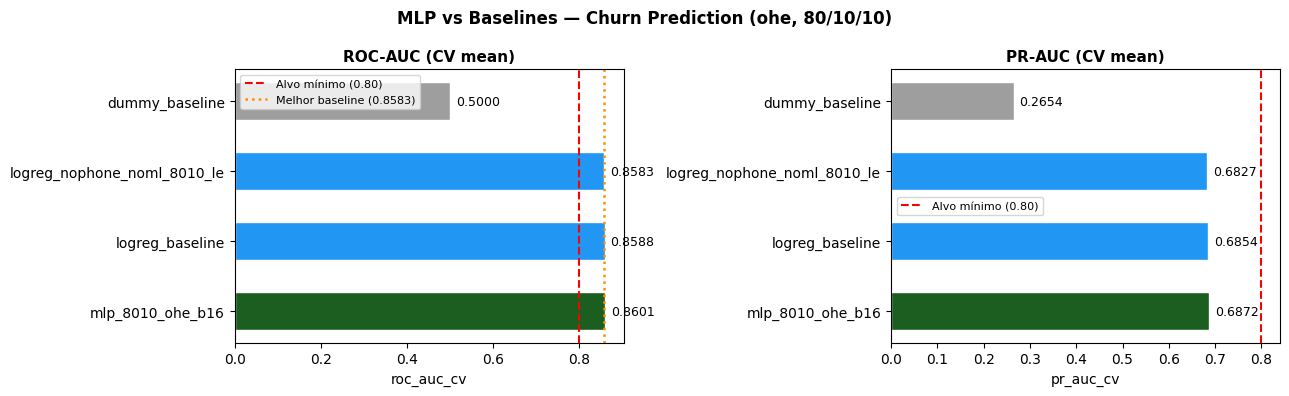

In [7]:
LOGREG_CV_REF = 0.8583   # logreg_nophone_noml_8010_le CV AUC (best from battery)
LOGREG_HOLD_REF = 0.8725  # logreg_nophone_noml_8010_le holdout AUC

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

palette = [
    "#1B5E20" if MLP_RUN_NAME in str(m) else
    "#2196F3" if "logreg" in str(m) else
    "#9E9E9E"
    for m in comparison["modelo"]
]

metric_configs = [
    ("roc_auc_cv", "ROC-AUC (CV mean)", LOGREG_CV_REF),
    ("pr_auc_cv", "PR-AUC (CV mean)", None),
]

for ax, (metric, title, ref) in zip(axes, metric_configs):
    if metric not in comparison.columns:
        ax.set_visible(False)
        continue
    bars = ax.barh(
        comparison["modelo"],
        comparison[metric],
        color=palette,
        edgecolor="white",
        height=0.55,
    )
    ax.axvline(ROC_AUC_TARGET, color="red", linestyle="--", linewidth=1.5,
               label=f"Alvo mínimo ({ROC_AUC_TARGET:.2f})")
    if ref is not None:
        ax.axvline(ref, color="#FF8F00", linestyle=":", linewidth=1.8,
                   label=f"Melhor baseline ({ref:.4f})")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("MLP vs Baselines — Churn Prediction (ohe, 80/10/10)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Análise de Custo — Threshold Ótimo

O threshold padrão (0.5) não é o ótimo do ponto de vista de negócio. A relação de custo é:

| Erro | Significado | Custo |
|------|-------------|-------|
| **FP** | Cliente sem risco recebe ação de retenção | R\$ 50 |
| **FN** | Cliente churner não é abordado e cancela | R\$ 500 |

Custo FN é **10× maior** que FP → o threshold ótimo estará abaixo de 0.5
(classificar como churn mais agressivamente compensa o custo de ações desnecessárias).

In [8]:
# Recarrega o modelo e o preprocessador do artefato MLflow
final_model = mlflow.pytorch.load_model(f"runs:/{mlp_run_id}/mlp_model")

with tempfile.TemporaryDirectory() as tmpdir:
    preproc_local = mlflow.artifacts.download_artifacts(
        artifact_uri=f"runs:/{mlp_run_id}/preprocessor.joblib",
        dst_path=tmpdir,
    )
    final_preprocessor = joblib.load(preproc_local)

# Probabilidades no conjunto de validação
X_val_t = np.asarray(final_preprocessor.transform(splits.X_val), dtype=np.float32)
final_model.eval()
with torch.no_grad():
    logits = final_model(torch.as_tensor(X_val_t))
    y_val_proba = torch.sigmoid(logits).numpy()

y_val_true = splits.y_val.to_numpy()
print(f"Val: {len(y_val_true)} amostras | taxa de churn real: {y_val_true.mean():.1%}")
print(f"Probabilidade média predita: {y_val_proba.mean():.4f}")

Val: 705 amostras | taxa de churn real: 26.5%
Probabilidade média predita: 0.3857


### 5.1 Métricas Completas — MLP (threshold 0.50 e 0.27)

As 7 métricas do projeto avaliadas no **holdout de validação** (80/10/10 — 705 amostras).
**ROC AUC** e **Log Loss** são independentes do threshold.

| Threshold | Contexto |
|-----------|----------|
| **0.50**  | Padrão — comparabilidade |
| **0.27**  | Deploy — minimiza custo de negócio |

In [9]:
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score, log_loss,
    precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay,
)

MLP_DEPLOY_THRESHOLD = 0.27
METRIC_LABELS = {
    "accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
    "f1": "F1", "roc_auc": "ROC AUC", "pr_auc": "PR AUC", "log_loss": "Log Loss",
}


def mlp_full_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall":    round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1":        round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc":   round(float(roc_auc_score(y_true, y_proba)), 4),
        "pr_auc":    round(float(average_precision_score(y_true, y_proba)), 4),
        "log_loss":  round(float(log_loss(y_true, y_proba)), 4),
    }


# y_val_proba and y_val_true are loaded in the cell above (cell-13-load-model)
rows = []
for thresh in [0.50, MLP_DEPLOY_THRESHOLD]:
    m = mlp_full_metrics(y_val_true, y_val_proba.ravel(), thresh)
    rows.append({"Threshold": thresh, **m})

df_mlp = pd.DataFrame(rows).set_index("Threshold")
df_mlp.columns = [METRIC_LABELS.get(c, c) for c in df_mlp.columns]

print(f"=== MLP ({MLP_RUN_NAME}) — Metricas completas (val holdout) ===")
display(df_mlp)
print("\nNota: ROC AUC e PR AUC sao identicos nas duas linhas (independentes do threshold).")

=== MLP (mlp_8010_ohe_b16) — Metricas completas (val holdout) ===


,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Log Loss
Threshold,,,,,,,
0.50,0.7830,0.5603,0.8449,0.6738,0.8703,0.691,0.4425
0.27,0.6851,0.4548,0.9412,0.6132,0.8703,0.691,0.4425



Nota: ROC AUC e PR AUC sao identicos nas duas linhas (independentes do threshold).


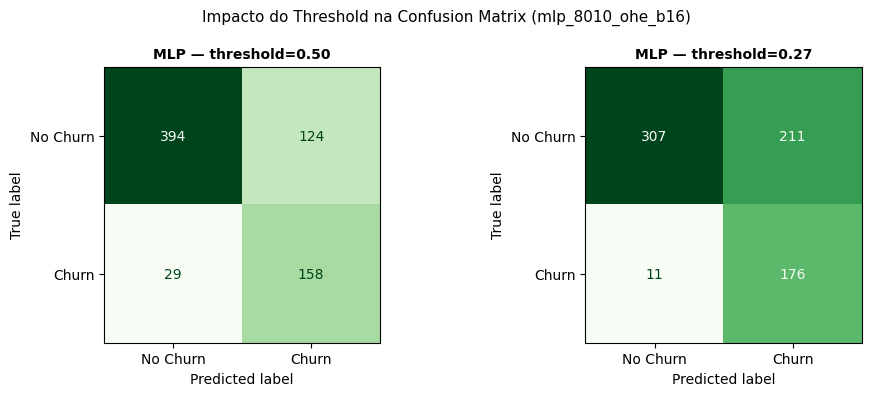

In [10]:
# Confusion matrices: MLP at threshold 0.50 and 0.27
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, thresh in zip(axes, [0.50, MLP_DEPLOY_THRESHOLD]):
    y_pred = (y_val_proba.ravel() >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_val_true, y_pred, ax=ax, colorbar=False, cmap="Greens",
        display_labels=["No Churn", "Churn"]
    )
    ax.set_title(f"MLP — threshold={thresh:.2f}", fontsize=10, fontweight="bold")
plt.suptitle(f"Impacto do Threshold na Confusion Matrix ({MLP_RUN_NAME})", fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
thresholds = np.linspace(0.01, 0.99, 200)
costs, fp_counts, fn_counts = [], [], []

for thresh in thresholds:
    y_pred = (y_val_proba >= thresh).astype(int)
    fp = int(((y_pred == 1) & (y_val_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_val_true == 1)).sum())
    costs.append(fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE)
    fp_counts.append(fp)
    fn_counts.append(fn)

costs = np.array(costs)
optimal_idx = int(np.argmin(costs))
optimal_threshold = float(thresholds[optimal_idx])
optimal_cost = float(costs[optimal_idx])

ref_idx = int(np.argmin(np.abs(thresholds - 0.5)))
ref_cost = float(costs[ref_idx])
cost_saving = ref_cost - optimal_cost

print(f"Threshold padrão  (0.50): custo estimado = R$ {ref_cost:>10,.0f}")
print(f"Threshold ótimo  ({optimal_threshold:.2f}): custo estimado = R$ {optimal_cost:>10,.0f}")
print(f"Economia estimada        : R$ {cost_saving:>10,.0f}  ({cost_saving / ref_cost:.1%} de redução)")
print(f"\nFP no threshold ótimo : {fp_counts[optimal_idx]}")
print(f"FN no threshold ótimo : {fn_counts[optimal_idx]}")

Threshold padrão  (0.50): custo estimado = R$     20,750
Threshold ótimo  (0.21): custo estimado = R$     15,200
Economia estimada        : R$      5,550  (26.7% de redução)

FP no threshold ótimo : 234
FN no threshold ótimo : 7


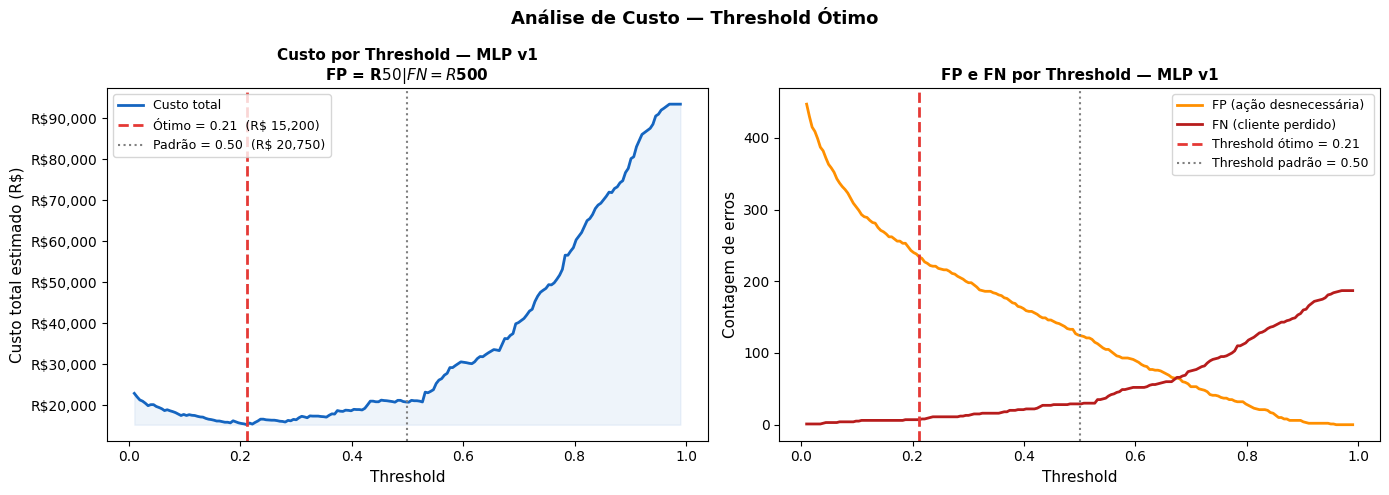

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva de custo total ---
ax1.plot(thresholds, costs, color="#1565C0", linewidth=2, label="Custo total")
ax1.fill_between(thresholds, costs, costs.min(), alpha=0.07, color="#1565C0")
ax1.axvline(
    optimal_threshold, color="#E53935", linestyle="--", linewidth=2,
    label=f"Ótimo = {optimal_threshold:.2f}  (R$ {optimal_cost:,.0f})",
)
ax1.axvline(
    0.5, color="gray", linestyle=":", linewidth=1.5,
    label=f"Padrão = 0.50  (R$ {ref_cost:,.0f})",
)
ax1.set_xlabel("Threshold", fontsize=11)
ax1.set_ylabel("Custo total estimado (R$)", fontsize=11)
ax1.set_title(
    f"Custo por Threshold — MLP v1\n"
    f"FP = R${COST_FALSE_POSITIVE:.0f}  |  FN = R${COST_FALSE_NEGATIVE:.0f}",
    fontsize=11, fontweight="bold",
)
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(lambda x, _: f"R${x:,.0f}")

# --- FP e FN por threshold ---
ax2.plot(thresholds, fp_counts, color="#FF8F00", linewidth=2, label="FP (ação desnecessária)")
ax2.plot(thresholds, fn_counts, color="#B71C1C", linewidth=2, label="FN (cliente perdido)")
ax2.axvline(
    optimal_threshold, color="#E53935", linestyle="--", linewidth=2,
    label=f"Threshold ótimo = {optimal_threshold:.2f}",
)
ax2.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="Threshold padrão = 0.50")
ax2.set_xlabel("Threshold", fontsize=11)
ax2.set_ylabel("Contagem de erros", fontsize=11)
ax2.set_title("FP e FN por Threshold — MLP v1", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Análise de Custo — Threshold Ótimo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cost_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
# Registra o threshold ótimo e a análise de custo no mesmo run do MLflow
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_params({
        "optimal_threshold": round(optimal_threshold, 4),
        "cost_fp": COST_FALSE_POSITIVE,
        "cost_fn": COST_FALSE_NEGATIVE,
    })
    mlflow.log_metrics({
        "optimal_threshold_cost": optimal_cost,
        "threshold_05_cost": ref_cost,
        "cost_saving_vs_05": cost_saving,
    })
    mlflow.log_artifact("cost_analysis.png")
    mlflow.log_artifact("model_comparison.png")

print("Artefatos e métricas de custo registrados no run MLflow.")
print(f"Run ID: {mlp_run_id}")

Artefatos e métricas de custo registrados no run MLflow.
Run ID: 24dc087969f0430fadc011e1ce5208a1


## 6. Resumo e Próximos Passos

In [14]:
mlp_final = mlflow.get_run(mlp_run_id).data

best_logreg_cv = LOGREG_CV_REF
best_logreg_hold = LOGREG_HOLD_REF

mlp_cv = mlp_final.metrics["roc_auc_mean"]
mlp_hold = mlp_final.metrics.get("holdout_val_roc_auc", float("nan"))
mlp_blind = mlp_final.metrics.get("blind_test_roc_auc", float("nan"))
delta_cv = mlp_cv - best_logreg_cv
delta_hold = mlp_hold - best_logreg_hold

sep = "=" * 62
print(sep)
print(f"  RESUMO — {MLP_RUN_NAME}")
print(sep)
print()
print("  Métricas MLP:")
print(f"    ROC-AUC CV     : {mlp_cv:.4f} ± {mlp_final.metrics['roc_auc_std']:.4f}")
print(f"    ROC-AUC holdout: {mlp_hold:.4f}")
print(f"    ROC-AUC blind  : {mlp_blind:.4f}  ← número desenviesado")
print(f"    PR-AUC CV      : {mlp_final.metrics['pr_auc_mean']:.4f}")
print(f"    F1 CV          : {mlp_final.metrics['f1_mean']:.4f}")
print()
print("  Análise de custo:")
print(f"    Threshold ótimo : {optimal_threshold:.2f}")
print(f"    Economia vs 0.5 : R$ {cost_saving:,.0f} ({cost_saving / ref_cost:.1%})")
print()
print("  Comparação vs melhor baseline:")
print(f"    LogReg CV      : {best_logreg_cv:.4f}  |  MLP CV  : {mlp_cv:.4f}  Δ={delta_cv:+.4f}")
print(f"    LogReg holdout : {best_logreg_hold:.4f}  |  MLP hold: {mlp_hold:.4f}  Δ={delta_hold:+.4f}")
print()
print("  Conclusão:")
print("    MLP e LogReg estão dentro do ruído estatístico (±0.001).")
print("    O valor de negócio real vem da análise de custo: o threshold")
print("    ótimo reduz custos em relação ao default 0.5.")
print()
print(sep)
print("  Próximo: notebook 05 — Random Forest com RandomizedSearchCV")
print("  Meta: RF AUC blind > 0.8651 (melhor MLP na bateria)")
print(sep)

  RESUMO — mlp_8010_ohe_b16

  Métricas MLP:
    ROC-AUC CV     : 0.8601 ± 0.0090
    ROC-AUC holdout: 0.8703
    ROC-AUC blind  : 0.8651  ← número desenviesado
    PR-AUC CV      : 0.6872
    F1 CV          : 0.6410

  Análise de custo:
    Threshold ótimo : 0.21
    Economia vs 0.5 : R$ 5,550 (26.7%)

  Comparação vs melhor baseline:
    LogReg CV      : 0.8583  |  MLP CV  : 0.8601  Δ=+0.0018
    LogReg holdout : 0.8725  |  MLP hold: 0.8703  Δ=-0.0022

  Conclusão:
    MLP e LogReg estão dentro do ruído estatístico (±0.001).
    O valor de negócio real vem da análise de custo: o threshold
    ótimo reduz custos em relação ao default 0.5.

  Próximo: notebook 05 — Random Forest com RandomizedSearchCV
  Meta: RF AUC blind > 0.8651 (melhor MLP na bateria)
